SECTION 1 — DATA UNDERSTANDING
Shape: (32581, 12)

Data Types:
 person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing %:
 pe

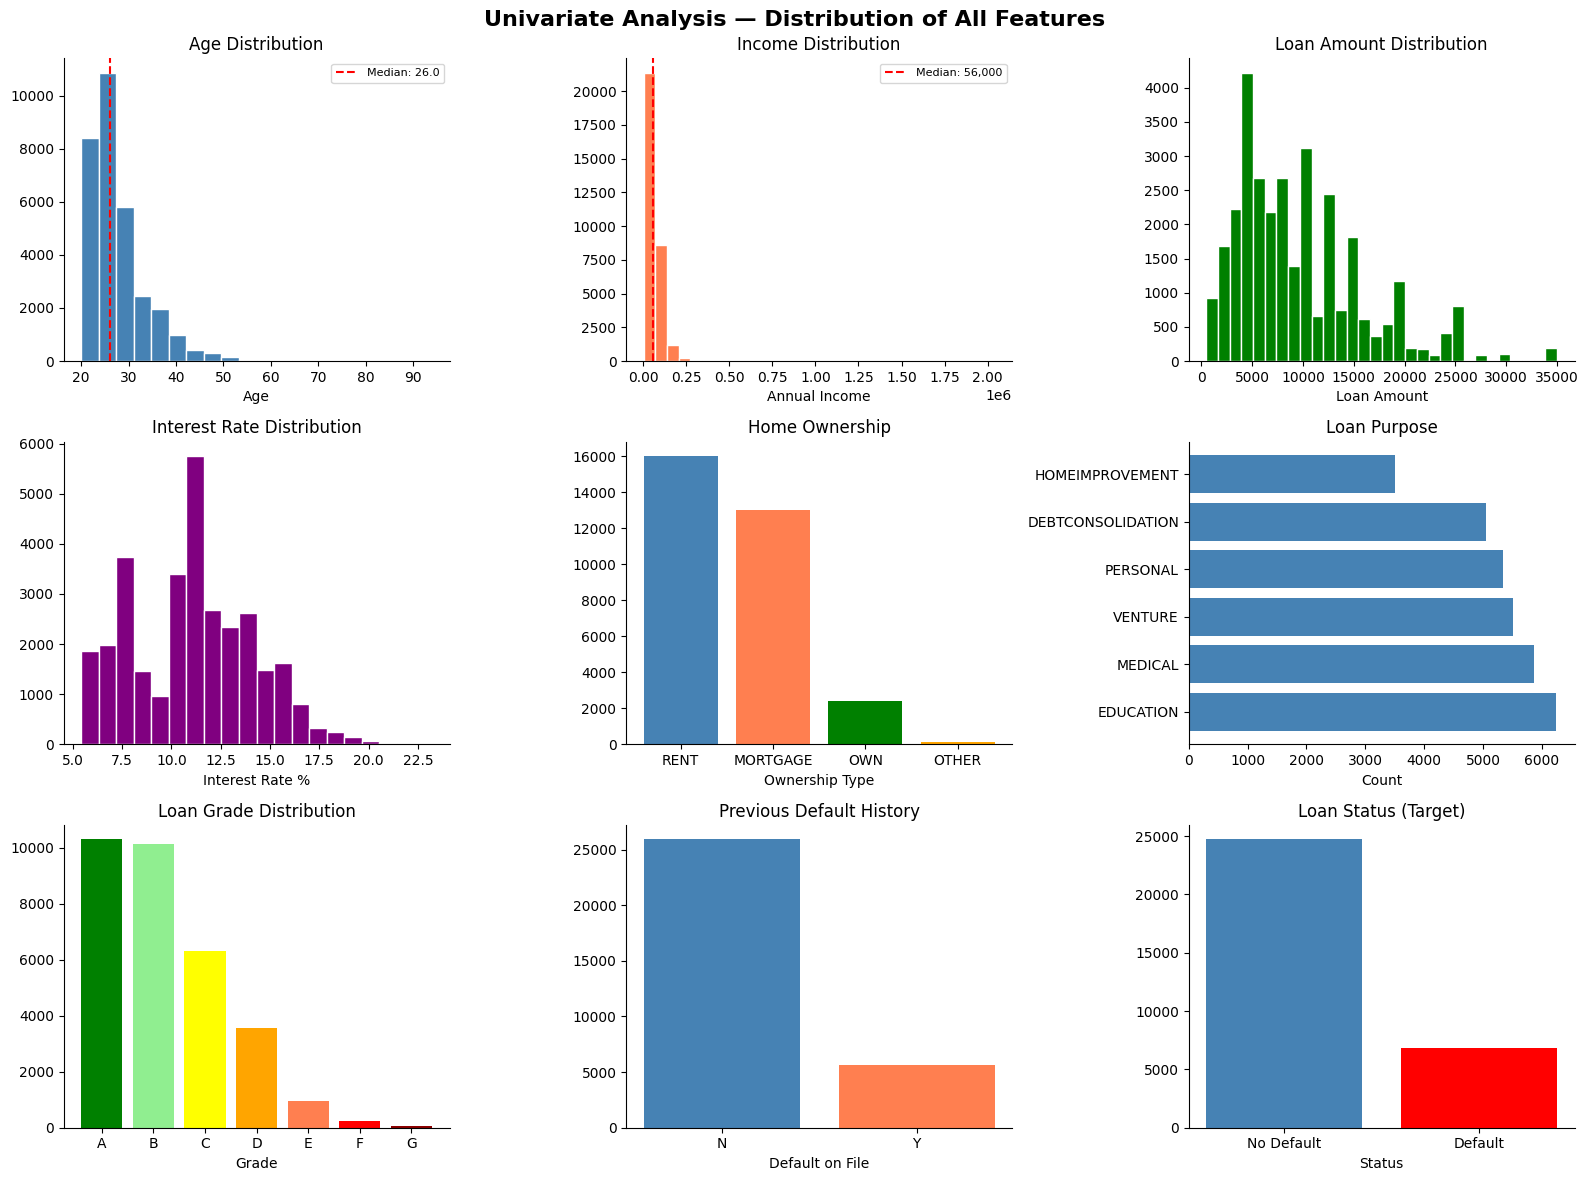


SECTION 4 — BIVARIATE ANALYSIS


/tmp/ipykernel_6034/1003620324.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([non_defaulters, defaulters],
/tmp/ipykernel_6034/1003620324.py:174: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([non_def_income, def_income],
/tmp/ipykernel_6034/1003620324.py:182: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot([non_def_rate, def_rate],


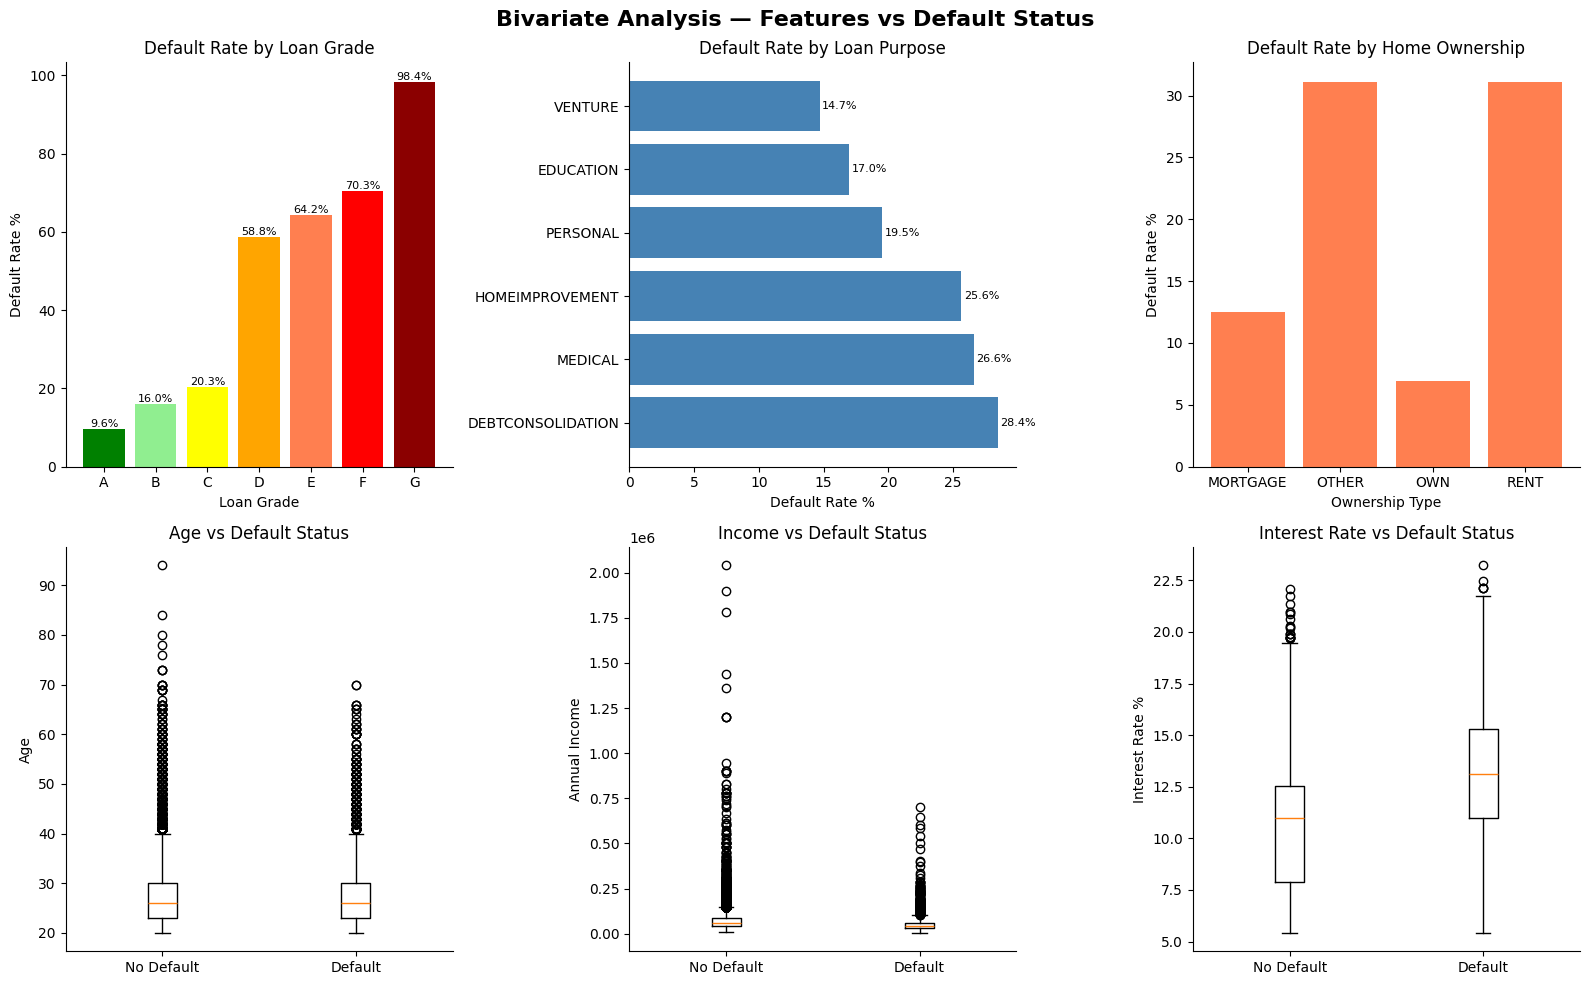


SECTION 5 — CORRELATION ANALYSIS


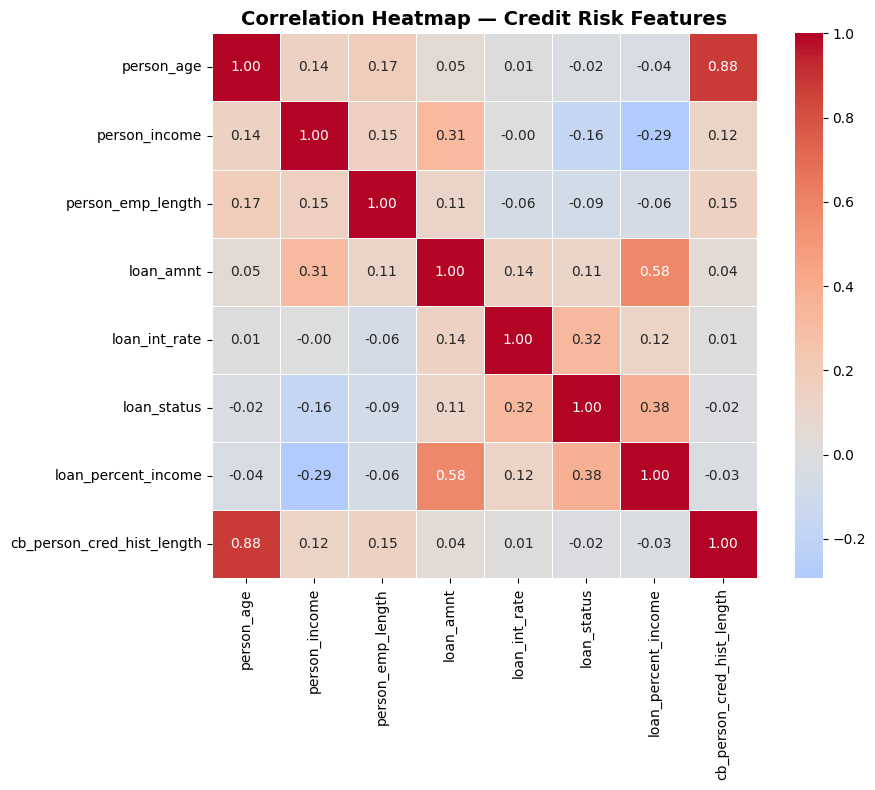


Correlation with Default Status:
loan_status                   1.000000
loan_percent_income           0.380069
loan_int_rate                 0.323899
loan_amnt                     0.112598
cb_person_cred_hist_length   -0.017781
person_age                   -0.023164
person_emp_length            -0.086313
person_income                -0.164862
Name: loan_status, dtype: float64

SECTION 6 — KEY VISUALIZATIONS


/tmp/ipykernel_6034/1003620324.py:249: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_default = df.groupby("income_bucket")["loan_status"].mean() * 100


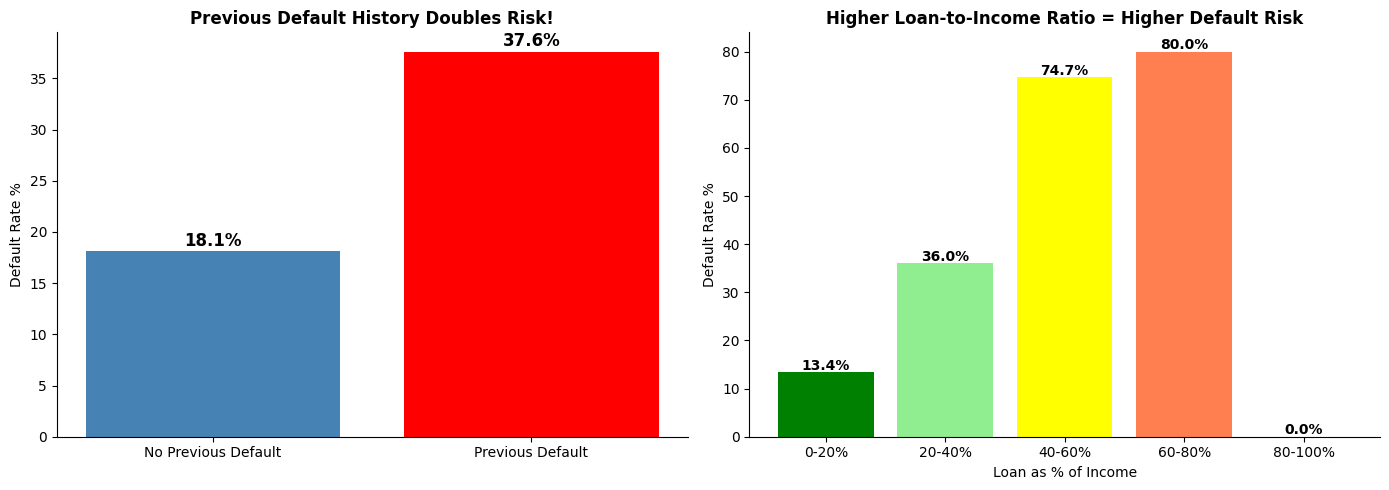


SECTION 7 — BUSINESS INSIGHTS

CREDIT RISK ANALYSIS — BUSINESS INSIGHTS

INSIGHT 1 — Overall Default Rate
Finding: 21.6% of all borrowers defaulted on their loans
Problem: This means 1 in every 5 loans results in a loss
Recommendation: Tighten loan approval criteria especially for Grade D and below

INSIGHT 2 — Loan Grade is the Strongest Predictor
Finding: Grade G loans have 98.4% default rate vs Grade A at 9.6%
Problem: Lower grade loans carry extremely high risk
Recommendation: Cap loan amounts for Grade D-G customers
                Charge higher interest rates to compensate for risk

INSIGHT 3 — Previous Default History Doubles the Risk
Finding: Customers with previous default have 37.6% default rate
         vs 18.1% for those with clean history
Problem: Previous defaulters are 2.1x more likely to default again
Recommendation: Require additional collateral from customers with default history
                Or reject loans above a threshold amount for this segment

INSIGHT 4 — L

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("credit_risk_dataset.csv")
# Step 1 — Understanding data
print("="*50)
print("SECTION 1 — DATA UNDERSTANDING")
print("="*50)
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nMissing %:\n", (df.isnull().sum()/len(df)*100).round(2))
print("\nStatistics:\n", df.describe())
print("\nDefault Rate:")
print(df["loan_status"].value_counts())
print(f"Default %: {df['loan_status'].mean()*100:.2f}%")


#Step 2 --- Clean the Data
print("\n"+"="*50)
print("Section 2 -- Data Cleaning")
print("="*50)

print("Before Cleaning: ",df.shape)

# Remove outliers in age — people over 100 are data errors
df = df[df["person_age"] <= 100]

# Remove outliers in employment length — over 60 years not realistic
df = df[df["person_emp_length"] <= 60]

# Fill missing values
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

print("After cleaning:", df.shape)
print("Remaining nulls:\n", df.isnull().sum())

#Step 3 -- Univariate Analysis
print("\n" + "="*50)
print("SECTION 3 — UNIVARIATE ANALYSIS")
print("="*50)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Univariate Analysis — Distribution of All Features",
             fontsize=16, fontweight="bold")

# Age distribution
axes[0,0].hist(df["person_age"], bins=20,
               color="steelblue", edgecolor="white")
axes[0,0].set_title("Age Distribution")
axes[0,0].set_xlabel("Age")
axes[0,0].axvline(df["person_age"].median(), color="red",
                  linestyle="--", label=f"Median: {df['person_age'].median()}")
axes[0,0].legend(fontsize=8)


# Income distribution
axes[0,1].hist(df["person_income"], bins=30,
               color="coral", edgecolor="white")
axes[0,1].set_title("Income Distribution")
axes[0,1].set_xlabel("Annual Income")
axes[0,1].axvline(df["person_income"].median(), color="red",
                  linestyle="--", label=f"Median: {df['person_income'].median():,.0f}")
axes[0,1].legend(fontsize=8)

# Loan amount
axes[0,2].hist(df["loan_amnt"], bins=30,
               color="green", edgecolor="white")
axes[0,2].set_title("Loan Amount Distribution")
axes[0,2].set_xlabel("Loan Amount")

# Interest rate
axes[1,0].hist(df["loan_int_rate"], bins=20,
               color="purple", edgecolor="white")
axes[1,0].set_title("Interest Rate Distribution")
axes[1,0].set_xlabel("Interest Rate %")

# Home ownership
home_counts = df["person_home_ownership"].value_counts()
axes[1,1].bar(home_counts.index, home_counts.values,
              color=["steelblue","coral","green","orange"])
axes[1,1].set_title("Home Ownership")
axes[1,1].set_xlabel("Ownership Type")

# Loan intent
intent_counts = df["loan_intent"].value_counts()
axes[1,2].barh(intent_counts.index, intent_counts.values,
               color="steelblue")
axes[1,2].set_title("Loan Purpose")
axes[1,2].set_xlabel("Count")

# Loan grade
grade_counts = df["loan_grade"].value_counts().sort_index()
axes[2,0].bar(grade_counts.index, grade_counts.values,
              color=["green","lightgreen","yellow","orange","coral","red","darkred"])
axes[2,0].set_title("Loan Grade Distribution")
axes[2,0].set_xlabel("Grade")

# Default on file
default_counts = df["cb_person_default_on_file"].value_counts()
axes[2,1].bar(default_counts.index, default_counts.values,
              color=["steelblue","coral"])
axes[2,1].set_title("Previous Default History")
axes[2,1].set_xlabel("Default on File")

# Loan status
status_counts = df["loan_status"].value_counts()
axes[2,2].bar(["No Default","Default"], status_counts.values,
              color=["steelblue","red"])
axes[2,2].set_title("Loan Status (Target)")
axes[2,2].set_xlabel("Status")


for ax in axes.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("univariate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

#Step 4 -- BIVARIATE ANALYSIS vs LOAN STATUS
print("\n" + "="*50)
print("SECTION 4 — BIVARIATE ANALYSIS")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Bivariate Analysis — Features vs Default Status",
             fontsize=16, fontweight="bold")

# Default rate by loan grade
grade_default = df.groupby("loan_grade")["loan_status"].mean().sort_index() * 100
axes[0,0].bar(grade_default.index, grade_default.values,
              color=["green","lightgreen","yellow","orange","coral","red","darkred"])
axes[0,0].set_title("Default Rate by Loan Grade")
axes[0,0].set_ylabel("Default Rate %")
axes[0,0].set_xlabel("Loan Grade")
for i, v in enumerate(grade_default.values):
    axes[0,0].text(i, v+0.5, f"{v:.1f}%", ha="center", fontsize=8)

# Default rate by loan intent
intent_default = df.groupby("loan_intent")["loan_status"].mean() * 100
intent_default = intent_default.sort_values(ascending=False)
axes[0,1].barh(intent_default.index, intent_default.values, color="steelblue")
axes[0,1].set_title("Default Rate by Loan Purpose")
axes[0,1].set_xlabel("Default Rate %")
for i, v in enumerate(intent_default.values):
    axes[0,1].text(v+0.2, i, f"{v:.1f}%", va="center", fontsize=8)

# Default rate by home ownership
home_default = df.groupby("person_home_ownership")["loan_status"].mean() * 100
axes[0,2].bar(home_default.index, home_default.values, color="coral")
axes[0,2].set_title("Default Rate by Home Ownership")
axes[0,2].set_ylabel("Default Rate %")
axes[0,2].set_xlabel("Ownership Type")

# Age vs Loan Status — boxplot
defaulters = df[df["loan_status"]==1]["person_age"]
non_defaulters = df[df["loan_status"]==0]["person_age"]
axes[1,0].boxplot([non_defaulters, defaulters],
                  labels=["No Default","Default"])
axes[1,0].set_title("Age vs Default Status")
axes[1,0].set_ylabel("Age")

# Income vs Loan Status — boxplot
def_income = df[df["loan_status"]==1]["person_income"]
non_def_income = df[df["loan_status"]==0]["person_income"]
axes[1,1].boxplot([non_def_income, def_income],
                  labels=["No Default","Default"])
axes[1,1].set_title("Income vs Default Status")
axes[1,1].set_ylabel("Annual Income")

# Interest Rate vs Loan Status
def_rate = df[df["loan_status"]==1]["loan_int_rate"]
non_def_rate = df[df["loan_status"]==0]["loan_int_rate"]
axes[1,2].boxplot([non_def_rate, def_rate],
                  labels=["No Default","Default"])
axes[1,2].set_title("Interest Rate vs Default Status")
axes[1,2].set_ylabel("Interest Rate %")

for ax in axes.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("bivariate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


# Step 5 — CORRELATION HEATMAP
print("\n" + "="*50)
print("SECTION 5 — CORRELATION ANALYSIS")
print("="*50)

fig, ax = plt.subplots(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()

sns.heatmap(correlation,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)
ax.set_title("Correlation Heatmap — Credit Risk Features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Print key correlations with loan_status
print("\nCorrelation with Default Status:")
print(correlation["loan_status"].sort_values(ascending=False))


# Step 6 — KEY VISUALIZATIONS
print("\n" + "="*50)
print("SECTION 6 — KEY VISUALIZATIONS")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Previous default history vs current default
prev_default = df.groupby("cb_person_default_on_file")["loan_status"].mean() * 100
colors = ["steelblue","red"]
axes[0].bar(["No Previous Default","Previous Default"],
            prev_default.values, color=colors)
axes[0].set_title("Previous Default History Doubles Risk!",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Default Rate %")
for i, v in enumerate(prev_default.values):
    axes[0].text(i, v+0.5, f"{v:.1f}%",
                 ha="center", fontweight="bold", fontsize=12)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Loan percent income vs default
df["income_bucket"] = pd.cut(df["loan_percent_income"],
                              bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                              labels=["0-20%","20-40%","40-60%","60-80%","80-100%"])
bucket_default = df.groupby("income_bucket")["loan_status"].mean() * 100
axes[1].bar(bucket_default.index, bucket_default.values,
            color=["green","lightgreen","yellow","coral","red"])
axes[1].set_title("Higher Loan-to-Income Ratio = Higher Default Risk",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Loan as % of Income")
axes[1].set_ylabel("Default Rate %")
for i, v in enumerate(bucket_default.values):
    axes[1].text(i, v+0.5, f"{v:.1f}%",
                 ha="center", fontweight="bold", fontsize=10)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("key_insights.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 7 — BUSINESS INSIGHTS
print("\n" + "="*50)
print("SECTION 7 — BUSINESS INSIGHTS")
print("="*50)

default_rate = df["loan_status"].mean() * 100
grade_g_default = grade_default.get("G", 0)
prev_default_yes = prev_default.get("Y", 0)
prev_default_no = prev_default.get("N", 0)

print(f"""
CREDIT RISK ANALYSIS — BUSINESS INSIGHTS
==========================================

INSIGHT 1 — Overall Default Rate
Finding: {default_rate:.1f}% of all borrowers defaulted on their loans
Problem: This means 1 in every {100/default_rate:.0f} loans results in a loss
Recommendation: Tighten loan approval criteria especially for Grade D and below

INSIGHT 2 — Loan Grade is the Strongest Predictor
Finding: Grade G loans have {grade_g_default:.1f}% default rate vs Grade A at {grade_default.get('A',0):.1f}%
Problem: Lower grade loans carry extremely high risk
Recommendation: Cap loan amounts for Grade D-G customers
                Charge higher interest rates to compensate for risk

INSIGHT 3 — Previous Default History Doubles the Risk
Finding: Customers with previous default have {prev_default_yes:.1f}% default rate
         vs {prev_default_no:.1f}% for those with clean history
Problem: Previous defaulters are {prev_default_yes/prev_default_no:.1f}x more likely to default again
Recommendation: Require additional collateral from customers with default history
                Or reject loans above a threshold amount for this segment

INSIGHT 4 — Loan-to-Income Ratio is a Key Risk Driver
Finding: Borrowers where loan exceeds 60% of income have very high default rates
Problem: These customers are financially over-stretched
Recommendation: Set a maximum loan-to-income ratio of 40% as lending policy

INSIGHT 5 — Loan Purpose Matters
Finding: Debt consolidation and home improvement loans have higher default rates
Problem: These loans may not generate income to repay
Recommendation: Prioritize education and medical loans which show lower default rates
                These have a clear purpose and borrowers are more motivated to repay
""")

# Step 8 — SUMMARY STATISTICS
print("="*50)
print("SECTION 8 — SUMMARY")
print("="*50)
print(f"Total records analyzed: {len(df):,}")
print(f"Overall default rate: {default_rate:.2f}%")
print(f"Average loan amount: ₹{df['loan_amnt'].mean():,.0f}")
print(f"Average interest rate: {df['loan_int_rate'].mean():.2f}%")
print(f"Average income: ₹{df['person_income'].mean():,.0f}")
print(f"Most common loan purpose: {df['loan_intent'].mode()[0]}")
print(f"Most common home ownership: {df['person_home_ownership'].mode()[0]}")
